<a href="https://www.kaggle.com/code/sonawanelalitsunil/bmw-sales-trends-2010-2024-ml-100?scriptVersionId=257111873" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bmw-sales2010-2024/BMW sales data (2010-2024).csv


## Title: 
BMW Sales Trends (2010–2024)

## Description:
This dataset covers BMW’s global sales performance from 2010 to 2024, highlighting year-on-year trends, market demand, and shifts in consumer preferences. It allows for a detailed analysis of sales growth, peak years, and downturns influenced by economic factors, evolving automotive technology, and customer adoption of electric vehicles. The dataset can be used to compare BMW’s position in the luxury automobile segment, study regional performance, and forecast future sales trends.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/bmw-sales2010-2024/BMW sales data (2010-2024).csv")

In [3]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [4]:
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [6]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [7]:
df.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
dtype: object

In [10]:
df.shape

(50000, 11)

In [11]:
df.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

## Data visualizations 

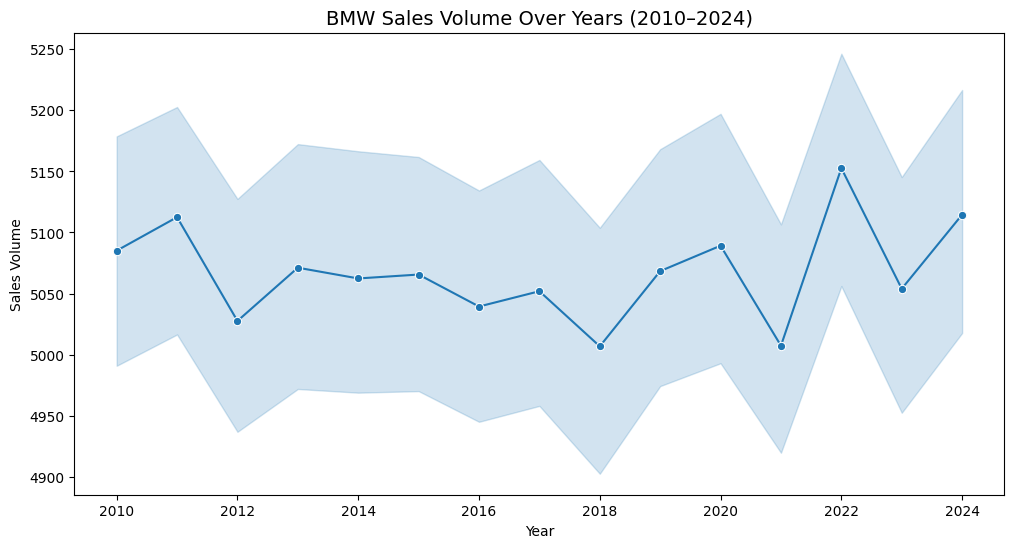

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Year", y="Sales_Volume", marker="o")
plt.title("BMW Sales Volume Over Years (2010–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sales Volume")
plt.show()

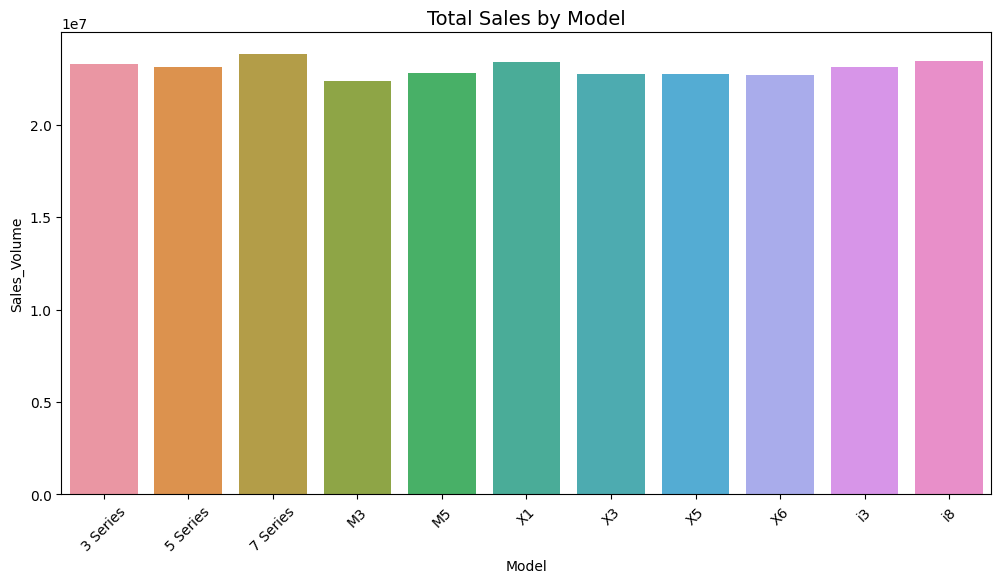

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(data=df.groupby("Model")["Sales_Volume"].sum().reset_index(),
            x="Model", y="Sales_Volume")
plt.title("Total Sales by Model", fontsize=14)
plt.xticks(rotation=45)
plt.show()

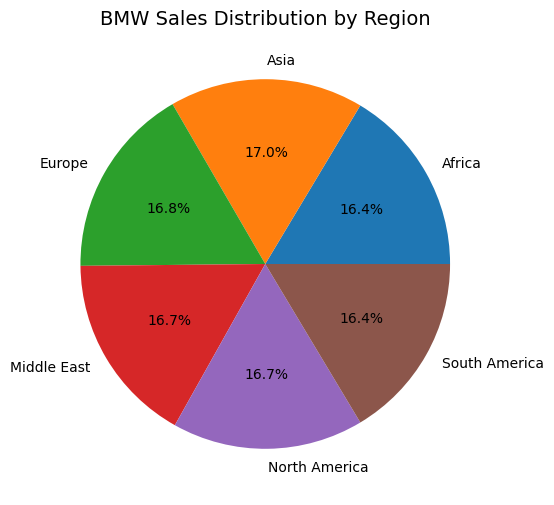

In [14]:
plt.figure(figsize=(10,6))
region_sales = df.groupby("Region")["Sales_Volume"].sum().reset_index()
plt.pie(region_sales["Sales_Volume"], labels=region_sales["Region"], autopct='%1.1f%%')
plt.title("BMW Sales Distribution by Region", fontsize=14)
plt.show()

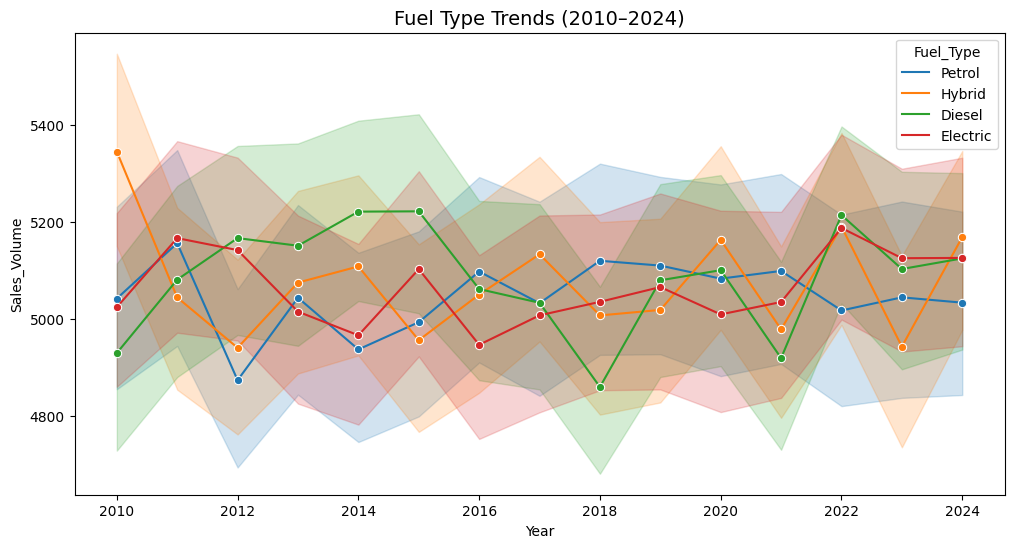

In [15]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Year", y="Sales_Volume", hue="Fuel_Type", marker="o")
plt.title("Fuel Type Trends (2010–2024)", fontsize=14)
plt.show()

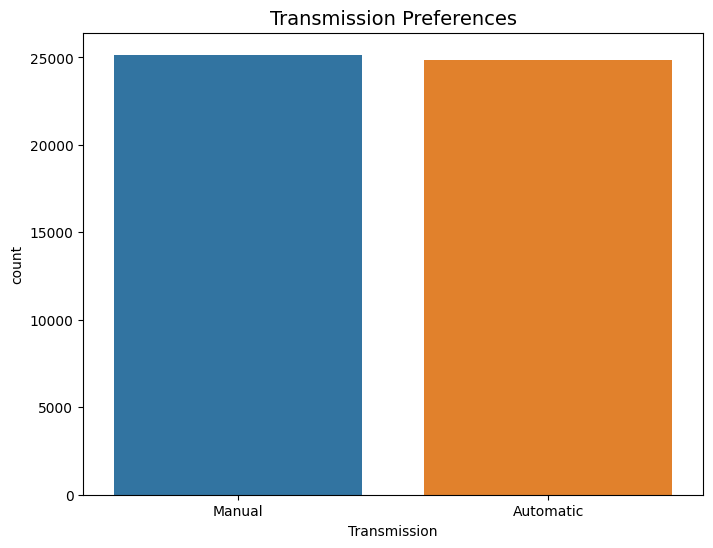

In [16]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Transmission")
plt.title("Transmission Preferences", fontsize=14)
plt.show()

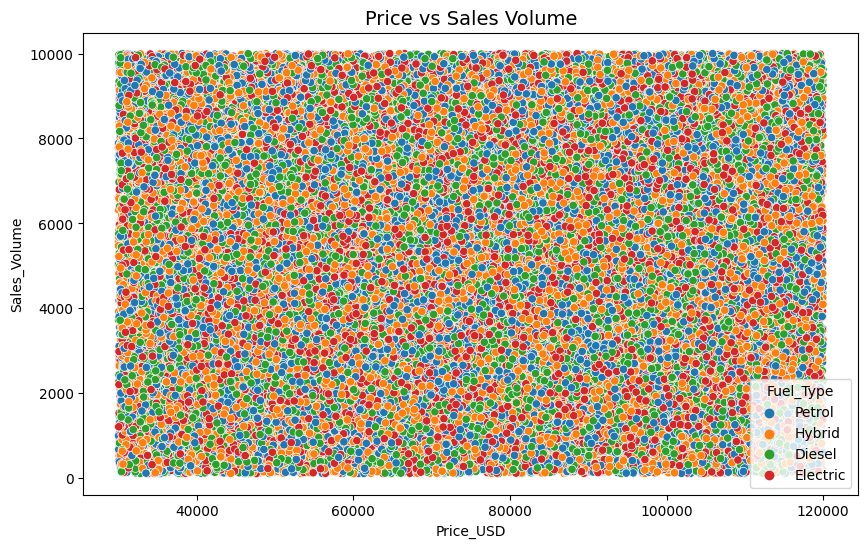

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Price_USD", y="Sales_Volume", hue="Fuel_Type")
plt.title("Price vs Sales Volume", fontsize=14)
plt.show()

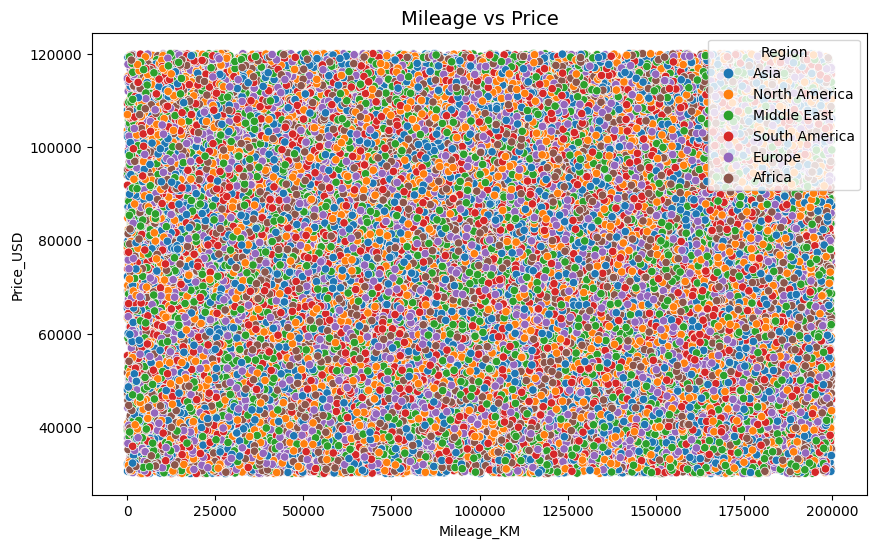

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Mileage_KM", y="Price_USD", hue="Region")
plt.title("Mileage vs Price", fontsize=14)
plt.show()

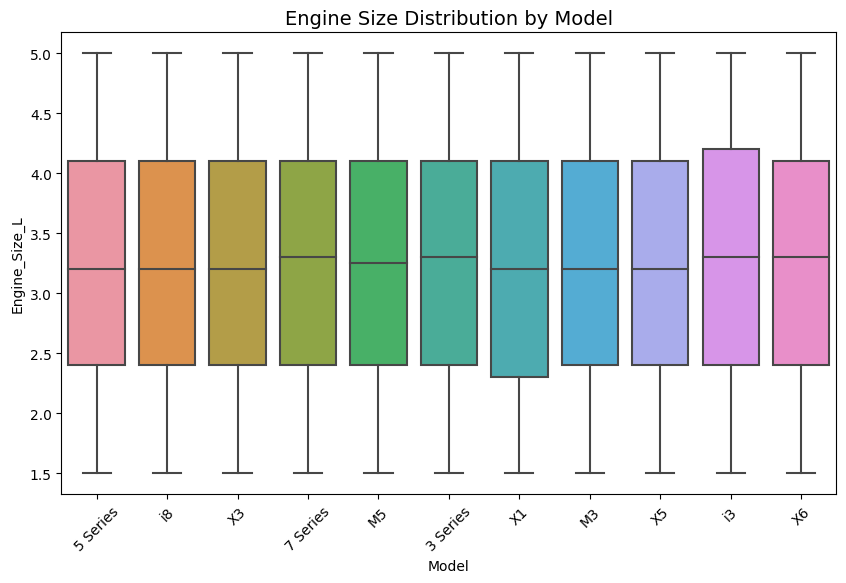

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Model", y="Engine_Size_L")
plt.title("Engine Size Distribution by Model", fontsize=14)
plt.xticks(rotation=45)
plt.show()

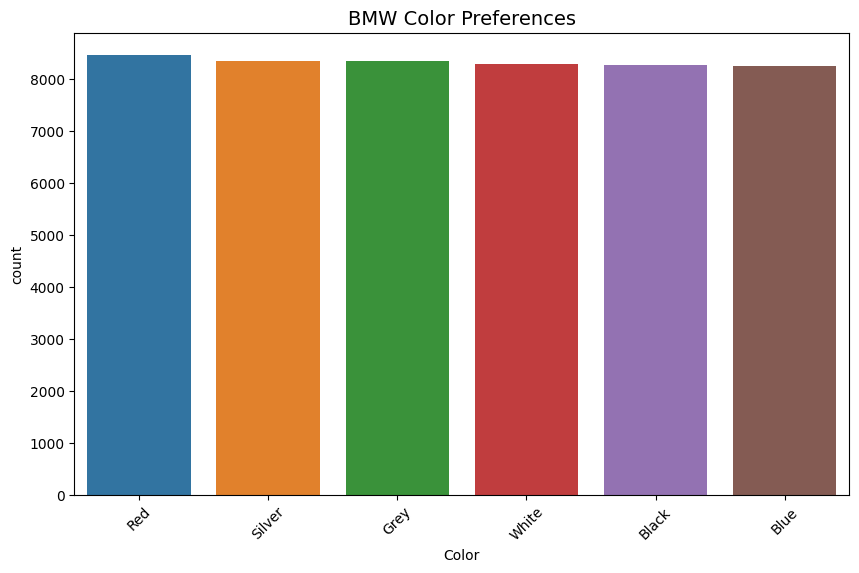

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Color", order=df['Color'].value_counts().index)
plt.title("BMW Color Preferences", fontsize=14)
plt.xticks(rotation=45)
plt.show()

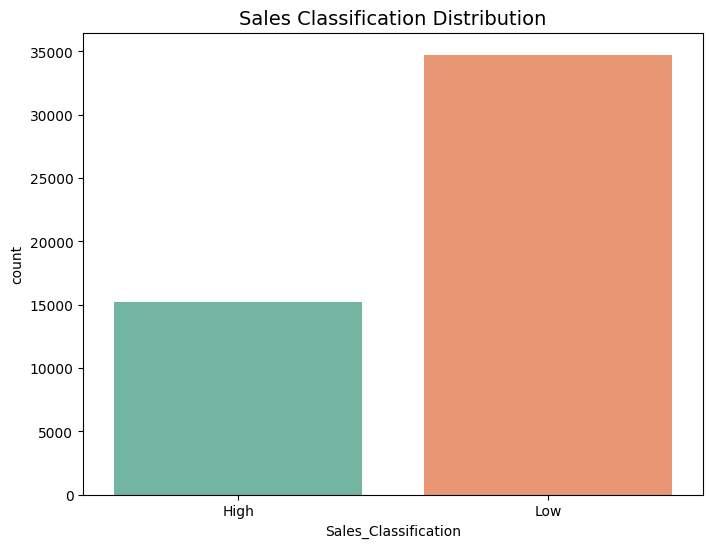

In [21]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Sales_Classification", palette="Set2")
plt.title("Sales Classification Distribution", fontsize=14)
plt.show()

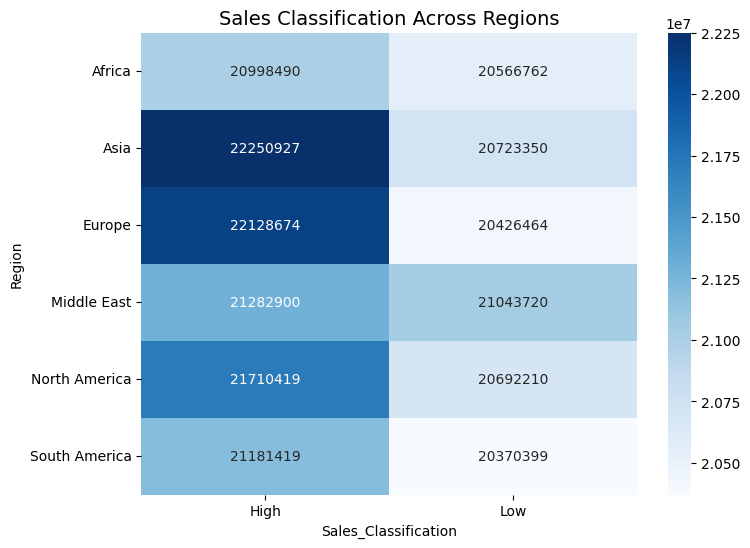

In [22]:
plt.figure(figsize=(8,6))
pivot = df.pivot_table(index="Region", columns="Sales_Classification", values="Sales_Volume", aggfunc="sum")
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales Classification Across Regions", fontsize=14)
plt.show()

## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [24]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [25]:
X = df.drop("Sales_Classification", axis=1)
y = df["Sales_Classification"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", use_label_encoder=False),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [27]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results.append([name, acc])


[LightGBM] [Info] Number of positive: 27803, number of negative: 12197
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001831 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 847
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.695075 -> initscore=0.823954
[LightGBM] [Info] Start training from score 0.823954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [28]:
results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression         99.84
1        Decision Tree        100.00
2        Random Forest        100.00
3    Gradient Boosting        100.00
4                  KNN         95.97
5                  SVM         99.58
6              XGBoost        100.00
7             LightGBM         99.92
8             CatBoost         99.98


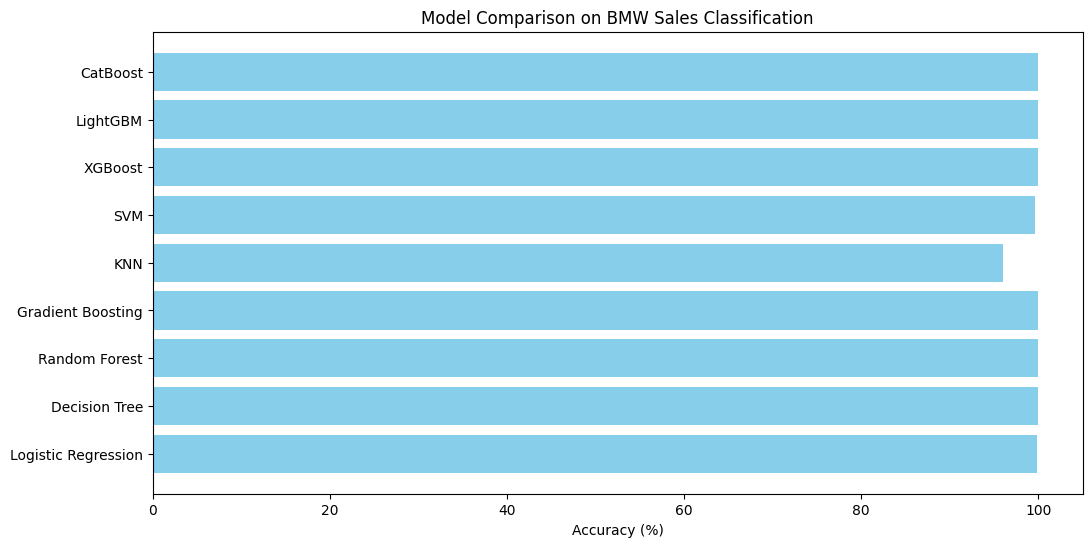

In [29]:
plt.figure(figsize=(12,6))
plt.barh(results_df["Algorithm"], results_df["Accuracy (%)"], color="skyblue")
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison on BMW Sales Classification")
plt.show()

## Thank you...pls upvote!!!